# AI534 Implementation 1###


**Team: IA1 8** (Manogna Challoju, Shanmukha Rangeneni)


**Deadline**: Sunday, Oct. 13, by 11:59pm

**Submission**: Submit 1) your completed notebook in ipynb format, and 2) a PDF export of the completed notebook with outputs (the codeblock at the end of the notebook should automatically produce the pdf file).

In this assignment, we will implement and experiment linear regression to predict the price of a house based on features describing the house, using the housing data that you have explored in the warm up assignment.

We will implement two versions, one using the closed-form solution, and one using gradient descent.

You may modify the starter code as you see fit, including changing the signatures of functions and adding/removing helper functions. However, please make sure that your TA can understand what you are doing and why.

First lets import the necessary packages.

In [63]:
!pip install nbconvert > /dev/null 2>&1
!pip install pdfkit > /dev/null 2>&1
!apt-get install -y wkhtmltopdf > /dev/null 2>&1
import os
import pdfkit
import contextlib
import sys
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# add more imports if necessary

# Part 0: (5 pts) data and preprocessing

---

On canvas, we have provided two different data files for this assignment: ia1_train.csv (for training) and ia1_val.csv(for validation). Download them and upload them to your google drive. Then mount the google drive from your google colab notebook:


In [69]:
from google.colab import drive
drive.mount('/content/gdrive')

train_path = '/content/gdrive/My Drive/AI534/ia1_train.csv' # DO NOT MODIFY THIS. Please make sure your data has this exact path
val_path = '/content/gdrive/My Drive/AI534/ia1_val.csv' # DO NOT MODIFY THIS. Please make sure your data has this exact path

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# Now load the training and validation data.

In [73]:
train_path = '/content/gdrive/My Drive/AI534/IA1_train.csv'
val_path = '/content/gdrive/My Drive/AI534/IA1_dev.csv'

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)

print("Training Data Sample:")
display(train_df.head())

print("\nValidation Data Sample:")
display(val_df.head())

Training Data Sample:


,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
0,7972604355,5/21/2014,3,1.00,1020,7874,1.0,0,0,3,...,1020,0,1956,0,98106,47.5175,-122.346,1290,7320,2.1800
1,8731951130,6/9/2014,3,2.25,2210,8000,2.0,0,0,4,...,2210,0,1969,0,98023,47.3085,-122.381,1990,8000,2.5025
2,7885800740,2/18/2015,4,2.50,2350,5835,2.0,0,0,3,...,2350,0,2003,0,98042,47.3494,-122.153,3010,5772,2.7000
3,4232900940,5/22/2014,3,1.50,1660,4800,2.0,0,0,3,...,1660,0,1907,0,98119,47.6352,-122.358,1690,4000,9.2630
4,3275850190,9/5/2014,3,2.50,2410,9916,2.0,0,0,4,...,2410,0,1989,0,98052,47.6911,-122.103,2310,8212,7.0000



Validation Data Sample:


,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
0,3211200460,8/6/2014,4,1.00,1520,9800,1.5,0,0,4,...,1520,0,1971,0,98034,47.7303,-122.236,1540,7700,3.8900
1,4124000320,3/16/2015,3,2.25,1800,15903,1.0,0,0,3,...,1340,460,1986,0,98038,47.3813,-122.043,2000,15233,3.3562
2,7129302800,12/12/2014,3,1.50,1780,5000,1.0,0,4,4,...,1030,750,1958,0,98118,47.5168,-122.256,1780,7500,4.2000
3,1392800035,6/18/2014,2,1.00,1240,6400,1.0,0,1,4,...,1060,180,1938,0,98126,47.5493,-122.377,1240,6400,5.5900
4,2154900040,10/30/2014,3,2.25,2190,8834,1.0,0,0,3,...,1390,800,1987,0,98001,47.2633,-122.244,1490,8766,1.9425


Perform the following preprocessing steps.
1. remove the *ID* column from both training and validation data
2. change *date* into 3 numerical features *day*, *month* and *year*, like in the warm up exercise
3. The feature *yr_renovated* is set to 0 if the house has not been renovated. This creates an inconsistent meaning to the numerical values. Replace it with a new feature called *age_since_renovated*:

>if *yr_renovate* != 0
>> *age_since_renovated* = *year* - *yr\_renovated*  

>otherwise
>> *age\_since\_renovated = year - yr\_built*

4. Normalize all the feautres using z-score normalization based on the training data. Do not normalize *price* as it is the target.
To normalize a feature *x* using z-score normalization, the fomula is

>$z=\frac{x-\mu}{\sigma}$

where $\mu$ and $\sigma$ are the mean and standard deviation of $x$ respectively. The normalized feature will have zero mean and unit standard deviation. Note that you should estimate $\mu$ and $\sigma$ for each feature only using the training data and use the same $\mu$ and $\sigma$ to normalize the features for both training and validation data.




In [74]:
train_df = train_df.drop(columns=['id'])
val_df = val_df.drop(columns=['id'])

for df in [train_df, val_df]:
    df['date'] = pd.to_datetime(df['date'])
    df['day'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df.drop(columns=['date'], inplace=True)

for df in [train_df, val_df]:
    df['age_since_renovated'] = df.apply(
        lambda row: row['year'] - row['yr_renovated'] if row['yr_renovated'] != 0 else row['year'] - row['yr_built'], axis=1
    )
    df.drop(columns=['yr_renovated'], inplace=True)

features_to_normalize = train_df.columns.difference(['price'])

train_mean = train_df[features_to_normalize].mean()
train_std = train_df[features_to_normalize].std()

train_df[features_to_normalize] = (train_df[features_to_normalize] - train_mean) / train_std
val_df[features_to_normalize] = (val_df[features_to_normalize] - train_mean) / train_std

Let's do a quick testing of your normalization, please
1. Estimate and print the new mean and standard deviation of the normalized features for the training data --- this should be 0 and 1 respectively.  
2. Estimate and print the new mean and standard deviation of the normalized features for the validation data --- these values will not be 0 and 1, but somewhat close

In [75]:
train_means_normalized = train_df[features_to_normalize].mean()
train_stds_normalized = train_df[features_to_normalize].std()

print("Training Data - Normalized Features")
print("Mean:")
display(train_means_normalized)
print("Standard Deviation")
display(train_stds_normalized)

val_means_normalized = val_df[features_to_normalize].mean()
val_stds_normalized = val_df[features_to_normalize].std()

print("\nValidation Data - Normalized Features")
print("Mean (should be close to 0):")
display(val_means_normalized)
print("Standard Deviation (should be close to 1):")
display(val_stds_normalized)

print("\nTraining Data Sample (after normalization):")
display(train_df.head())

print("\nValidation Data Sample (after normalization):")
display(val_df.head())

Training Data - Normalized Features
Mean:


,0
age_since_renovated,-9.681145e-17
bathrooms,-1.634248e-16
bedrooms,1.652012e-16
condition,6.306067e-17
day,-2.142730e-17
floors,4.396483e-17
grade,1.207923e-16
lat,-4.131451e-14
long,9.379608e-14
month,-2.264855e-17


Standard Deviation


,0
age_since_renovated,1.0
bathrooms,1.0
bedrooms,1.0
condition,1.0
day,1.0
floors,1.0
grade,1.0
lat,1.0
long,1.0
month,1.0



Validation Data - Normalized Features
Mean (should be close to 0):


...

,0
age_since_renovated,0.999477
bathrooms,1.003430
bedrooms,0.893240
condition,0.976223
day,1.008404
floors,0.992549
grade,1.033680
lat,1.000963
long,0.986680
month,0.983898



Training Data Sample (after normalization):


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,zipcode,lat,long,sqft_living15,sqft_lot15,price,day,month,year,age_since_renovated
0,-0.388520,-1.465613,-1.159110,-0.171139,-0.922332,-0.082432,-0.304487,-0.634184,-0.563015,-0.924206,...,0.512279,-0.308988,-0.932779,-1.018504,-0.185644,2.1800,0.600423,-0.513736,-0.682211,0.587803
1,-0.388520,0.169158,0.145003,-0.168133,0.917732,-0.082432,-0.304487,0.888924,0.290361,0.507090,...,-1.040633,-1.816632,-1.179633,0.004058,-0.162508,2.5025,-0.793714,-0.193377,-0.682211,0.137857
2,0.649956,0.496112,0.298428,-0.219787,0.917732,-0.082432,-0.304487,-0.634184,0.290361,0.675478,...,-0.685148,-1.521596,0.428443,1.494077,-0.238313,2.7000,0.251889,-1.474814,1.465639,-1.004315
3,-0.388520,-0.811705,-0.457738,-0.244481,0.917732,-0.082432,-0.304487,-0.634184,0.290361,-0.154433,...,0.755506,0.540053,-1.017415,-0.434182,-0.298603,9.2630,0.716601,-0.513736,-0.682211,2.283754
4,-0.388520,0.496112,0.364182,-0.122419,0.917732,-0.082432,-0.304487,0.888924,1.997115,0.747644,...,-0.498050,0.943294,0.781091,0.471515,-0.155295,7.0000,-1.258427,0.767701,-0.682211,-0.554368



Validation Data Sample (after normalization):


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,zipcode,lat,long,sqft_living15,sqft_lot15,price,day,month,year,age_since_renovated
0,0.649956,-1.465613,-0.611163,-0.125186,-0.002300,-0.082432,-0.304487,0.888924,-0.563015,-0.322821,...,-0.834826,1.226067,-0.156953,-0.653303,-0.172715,3.8900,-1.142248,0.447342,-0.682211,0.068634
1,-0.388520,0.169158,-0.304313,0.020425,-0.922332,-0.082432,-0.304487,-0.634184,0.290361,-0.539319,...,-0.759987,-1.291481,1.204269,0.018666,0.083587,3.3562,0.019532,-1.154455,1.465639,-0.415923
2,-0.388520,-0.811705,-0.326231,-0.239710,-0.922332,-0.082432,5.014070,0.888924,-0.563015,-0.912178,...,0.736796,-0.314038,-0.298012,-0.302710,-0.179520,4.2000,-0.445180,1.728779,-0.682211,0.518580
3,-1.426996,-1.465613,-0.918013,-0.206307,-0.922332,-0.082432,1.025152,0.888924,-0.563015,-0.876095,...,0.886474,-0.079596,-1.151421,-1.091544,-0.216946,5.5900,0.251889,-0.193377,-0.682211,1.210806
4,-0.388520,0.169158,0.123085,-0.148234,-0.922332,-0.082432,-0.304487,-0.634184,-0.563015,-0.479181,...,-1.452249,-2.142687,-0.213377,-0.726343,-0.136445,1.9425,1.646026,1.088060,-0.682211,-0.485146



## ***Question***
Why is it import to use the same $\mu$ and $\sigma$ to perform normalization on the training and validation data? What would happen if we use $\mu$ and $\sigma$ estimated using the validation to perform normalization on the validation data?  


Using the same mean (𝜇) and standard deviation (𝜎) for normalizing both the training and validation data is crucial because it ensures that the model is trained and evaluated on a consistent scale, allowing the model to learn and be tested properly. If we normalize the validation data using its own mean and standard deviation, the model could unintentionally pick up information from that data during training. This can make the model appear to perform better than it really does, leading to inaccurate predictions when it faces new data in the real world.


# Part 1 (15 pts) Generate closed-form solution for reference.
Our data now contains 21 numeric features, before we learn a linear regression model using gradient descent, we will first build the closed-form solution as a reference point. So for this part, you need to
1. Implement the close-form solution for linear regression and apply it to the training data to learn the weight vector for your linear regression model. For matrix inversion you can use existing numpy functions. Specifically, we recommend the numpy.linalg.pinv() function for inverting near-singular matrices.
2. Apply your learned linear regression model to the training data to make predictions for all training examples and report the Mean Squared Error.
3. Apply your learned linear regression model to the validation data to make predictions for all the validation examples and report the mean squared error for the validation data.

Your code should print the weight vector, which has 22 dimensions, one for each feature plus one additional $w_0$.  Your code should also report the MSE for the training and validation data respectively.

In [76]:
features = train_df.columns.difference(['price'])

X_train = np.c_[np.ones(train_df.shape[0]), train_df[features]]
y_train = train_df['price'].values
X_val = np.c_[np.ones(val_df.shape[0]), val_df[features]]
y_val = val_df['price'].values

w = np.linalg.pinv(X_train.T @ X_train) @ X_train.T @ y_train

train_pred = X_train @ w
train_mse = np.mean((y_train - train_pred) ** 2)
print("Training MSE:", train_mse)

val_pred = X_val @ w
val_mse = np.mean((y_val - val_pred) ** 2)
print("Validation MSE:", val_mse)

weight_vector = pd.Series(w, index=['w0'] + list(features))
display(weight_vector)

print("Length of weight vector (w):", len(w))
print("Length of index list (including 'w0'):", len(['w0'] + list(features)))


Training MSE: 3.757887089954586
Validation MSE: 4.5035081053568575


,0
w0,5.361673
age_since_renovated,-0.102558
bathrooms,0.339072
bedrooms,-0.281353
condition,0.199843
day,-0.050637
floors,0.018137
grade,1.115443
lat,0.836612
long,-0.303696


Length of weight vector (w): 22
Length of index list (including 'w0'): 22


## Question
The learned feature weights are often used  to understand the importance of the features. The sign of the weights indicates if a feature positively or negatively impact the price, and the magnitude suggests the strength of the impact. Does the sign of all the features match your expection based on your common-sense understanding of what makes a house expensive? Please hightlight any surprises from the results.


Most feature weights align with our expectations regarding house pricing. Positive impact features like bathrooms, grade, lat, view, sqft_living, and waterfront are making the house expensive. These make intuitive sense, as buyers often value more bathrooms, higher quality (grade), scenic views, larger living spaces, and waterfront access.

But on the other hand, some features, like the year built and zipcode, have negative weights, indicating they tend to lower the price. This could mean that older homes or certain areas might be less desirable, which is also reasonable in many cases.

However, there are some surprises in the data. For instance, bedrooms have a negative weight, suggesting that simply adding more bedrooms doesn’t necessarily increase a home’s value in this dataset. This might imply that buyers are prioritizing other factors over just the number of bedrooms. Another unexpected finding is the negative weight on `sqft_lot15`. With a weight of -0.099, it implies that larger lot sizes don’t always add value, which goes against the common belief that more land should increase a property’s value. This could be due to neighborhood characteristics or the way lot size interacts with other features in the data.


# Part 2 (40 pts) Implement and experiment with batch gradient descent

Your implementation should take following inputs:

1. the training data (with $d$ features and 1 target variable $y$),

2. the learning rate $\gamma$,

3. the number of iterations $T$

4. Optional convergence threshold (optional) $\epsilon_l$ for the loss or $\epsilon_g$ for the norm of the gradient

It should output:
1. the learned $d+1$ - dimensional weight vector
2. the sequence of $T$ MSE losses, one for each training epoch. You will be asked to plot the losses as a function of training epoch later.


In [77]:
def batch_gradient_descent(X, y, learning_rate, num_iterations, epsilon=None, convergence_threshold=None):
    X = np.c_[np.ones(X.shape[0]), X]

    weights = np.random.randn(X.shape[1])
    losses = []

    for _ in range(num_iterations):
        gradients = 2 / len(X) * X.T.dot(X.dot(weights) - y)
        weights -= learning_rate * gradients

        mse = np.mean((X.dot(weights) - y) ** 2)
        losses.append(mse)

        if (epsilon and mse < epsilon) or (convergence_threshold and np.linalg.norm(gradients) < convergence_threshold):
            break

    return weights, losses

#example
batch_gradient_descent(
    train_df[features],
    y_train,
    learning_rate=0.05,
    num_iterations=1000,
    epsilon=1e-4,
    convergence_threshold=1e-4
)

(array([ 5.36167284, -0.10217076,  0.33907827, -0.28134638,  0.19982005,
        -0.05064146,  0.01814189,  1.11546834,  0.83660836, -0.3036956 ,
         0.05479668,  0.25830447, -0.10601228,  1.30990867,  0.1435462 ,
         0.05811468, -0.09923711,  0.44676535,  0.32814223,  0.1736877 ,
        -0.88299302, -0.26341713]),
 [57.579327873647635,
  44.05651309857181,
  34.80276367439203,
  28.06577475194115,
  23.008920357186692,
  19.138559724408996,
  16.13294175452952,
  13.77190845336726,
  11.900101090182698,
  10.405175930693622,
  9.204161330391207,
  8.234641461641482,
  7.448919102535408,
  6.810061294202792,
  6.289158773833718,
  5.863383558760532,
  5.51458248941883,
  5.22823861483329,
  4.992690669420886,
  4.798537567933039,
  4.638178234856219,
  4.505452250489709,
  4.395356813526945,
  4.303822270858995,
  4.227533111083625,
  4.163784583590862,
  4.110367447953389,
  4.065475072097797,
  4.027628373495675,
  3.9956150621418054,
  3.9684403830753725,
  3.945287128762

You will now experiment with the batch gradient descent algorithm with different learning rate on the provided data.

Please train your model for up to 3000 iterations using different learning rate: $\gamma=10^{-i}$, $i=0,1,...,4$. For each learning rate, you can opt to stop early if it has converged (using the convergence threshold) or diverged (the loss start to grow larger).

For each converging (not necessarily converged yet) learning rate, please compute and report the MSE of the final learned weights on the validation data.

Also please provide a plot that shows the training loss curves (MSE as a function of the # of epochs) for all the converging learning rates. Please use different colors mark different learning rates and provide proper legends for your figure.


/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
<ipython-input-77-4e299f36a189>:11: RuntimeWarning: overflow encountered in square
  mse = np.mean((X.dot(weights) - y) ** 2)


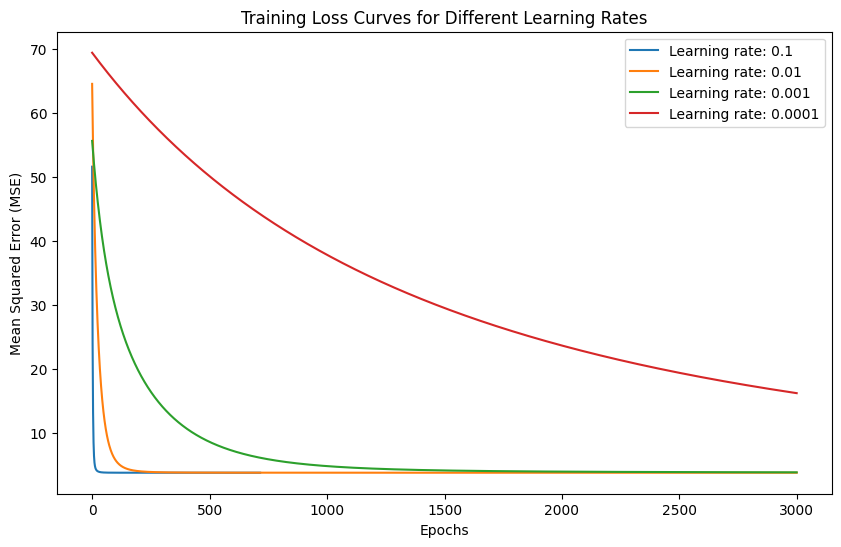

Learning rate: 1, Validation MSE: nan
Learning rate: 0.1, Validation MSE: 4.503508090163732
Learning rate: 0.01, Validation MSE: 4.503498111507704
Learning rate: 0.001, Validation MSE: 4.539809995982212
Learning rate: 0.0001, Validation MSE: 16.615115268273815


In [78]:
learning_rates = [10**-i for i in range(5)]
num_iterations = 3000
convergence_threshold = 1e-6
epsilon = 1e-8

weights_list = []
validation_mses = []
all_losses = []

for lr in learning_rates:
    weights, losses = batch_gradient_descent(train_df[features], y_train, lr, num_iterations, epsilon, convergence_threshold)
    weights_list.append(weights)
    all_losses.append(losses)

    X_val_b = np.c_[np.ones(val_df.shape[0]), val_df[features]]
    y_val_pred = X_val_b.dot(weights)
    mse_val = np.mean((y_val_pred - y_val) ** 2)
    validation_mses.append(mse_val)

plt.figure(figsize=(10, 6))
for i, losses in enumerate(all_losses):
    if learning_rates[i] == 1:
        continue
    plt.plot(losses, label=f'Learning rate: {learning_rates[i]}')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training Loss Curves for Different Learning Rates')
plt.legend()
plt.show()

for lr, mse in zip(learning_rates, validation_mses):
    print(f"Learning rate: {lr}, Validation MSE: {mse}")


## Question

Which learning rate leads to the best trainng and validation MSE respectively? Do you observe better training MSE tend to correpsond to better validation MSE? How is this different from the trend shown on page 51 of the lecture slides (titled danger of using training loss to select M) regarding overfitting? Is there any issue with using training loss to pick learning rate in this case?

1. The best learning rate is the one that gives the lowest validation MSE which is 0.01 in our case, as that shows your model is performing well on new, unseen data. While a lower training MSE is usually a good sign, it’s important to see if it aligns with a low validation MSE.

2. In an ideal scenario, a lower training MSE should generally correspond to a lower validation MSE, showing that the model is learning well from the data and generalizing properly, but if the training MSE is much lower than the validation MSE, this is often bad for overfitting, meaning the model is not performing well on data it hasn’t seen before.

3.  As the model complexity (𝑀) increases, training loss keeps going down, suggesting the model is improving. However, validation loss the measure of how well the model performs on new data—initially drops and then starts to rise, which signals overfitting. This means the model is fitting the training data well but isn’t generalizing to new data.The same issue can occur when picking a learning rate. A rate that minimizes training MSE doesn’t always minimize validation MSE. If the training MSE is much lower than the validation MSE, it likely indicates overfitting, where the model memorizes the training data but performs poorly on unseen data. To avoid this, it’s important to look at both training and validation MSE. This way, you can choose a learning rate that balances good training performance with strong generalization to new data, reducing the risk of overfitting.

4. Relying solely on training loss to pick a learning rate can be risky as you could end up with a learning rate that allows the model to overfit the training data, resulting in poor performance on validation data. By considering both training and validation MSE, you’re more likely to find a learning rate that balances effective learning with good generalization, which helps avoid overfitting.


# Part 3. More exploration.

## **3(a). (20 pts) Normalization of features: what is the impact?**
In part 1, you were asked to perform z-score normalization of all the features. In this part, we will ask you to first conceptually think about what is the impact this operation on the solution and then use some experiments to varify your conceptual understanding.

### **Questions.**

The normalization process applies a linear transformation to each feature, where the transformed feature $x'$ is simply a linear function of original feature $x$: $x'=\frac{x-\mu}{\sigma}$.

Let's disect the influence of this transformation on our learned linear regression model.
1. How do you think this transformation will influnce the training and validation MSE we get for the closed-form solution? Why?
2. How do you think this will change the magnitude of the weights of the learned model? Why?
3. How do you think this will change the convergence behavior of the batch gradient descent algorithm? Why?

1. By normalizing the features, we make sure that all the features contribute equally to the model. This helps the model learn better patterns in the data and reduce overfitting. Since all features are transformed to have a mean of 0 and a standard deviation of 1, the model can find patterns more easily. This often results in a lower Mean Squared Error (MSE) during both training and validation because the predictions are more aligned with the actual target values. Utlimately this leads to better performance on both training and validation datasets

2. Normalising the features will affect the size of the weights in the trained model because it adjusts the features to a consistent range, usually centered around a mean of 0 with a standard deviation of 1. This adjustment enables the model to concentrate on the connections between the features and the target variable without being swayed by the original scales of the features. As a result, the learned weights may become smaller in magnitude, reflecting the relative importance of each feature in a more balanced way. This process helps ensure that features with larger ranges do not influence the model's predictions.

3. Normalization can speed up the learning process because the model’s updates are more stable. When features are on the same scale, the algorithm can take larger steps toward finding the best weights without overshooting. With normalized data, the gradient descent algorithm is less likely to bounce around and more likely to make steady progress toward the solution, leading to smoother learning.


Now please perform the following experiments to verify your answer to the above questions.
1. Apply closed-form solution to data that did not go through the feature normalization step, and report the learned weights and the resulting training and testing MSEs.
2. Apply gradient descent algorithm to data that did not go through the feature normalization step using different learning rate. Note that the learning rate used in previous section will no longer work here. You will need to search for an appropriate learning rate to get some converging behavior. Plot your MSE loss curve as a function of the epochs once you identify a convergent learning rate.
Hint: the learning rate needs to be much, much, much, much, much smaller (think about each much as an order of manitude) than what was used in part 2). Also unless you let it run for a long time, it is unlikely to converge to the same level of loss values. So use a upper bound on the # of iterations so that it won't take forever.

Weights

Feature: intercept, Weight: 0.0001808332051459062
Feature: age_since_renovated, Weight: -0.0031683550200548275
Feature: bathrooms, Weight: 0.44004184947541874
Feature: bedrooms, Weight: -0.29494358813734634
Feature: condition, Weight: 0.2907117793248176
Feature: day, Weight: -0.006969491176609143
Feature: floors, Weight: 0.04483023323982918
Feature: grade, Weight: 0.951607363923924
Feature: lat, Weight: 6.0087155245200075
Feature: long, Weight: -2.135938805463776
Feature: month, Weight: -0.023201459599702504
Feature: sqft_above, Weight: 0.0007635994619053514
Feature: sqft_basement, Weight: 0.00022068177896200885
Feature: sqft_living, Weight: 0.0009842732372912447
Feature: sqft_living15, Weight: 0.00019448131797468582
Feature: sqft_lot, Weight: 1.3494867921265564e-06
Feature: sqft_lot15, Weight: -3.4334744834654583e-06
Feature: view, Weight: 0.5987603181555551
Feature: waterfront, Weight: 4.017621503759493
Feature: year, Weight: 0.0244379978471295
Feature: yr_built, Weight: -0.

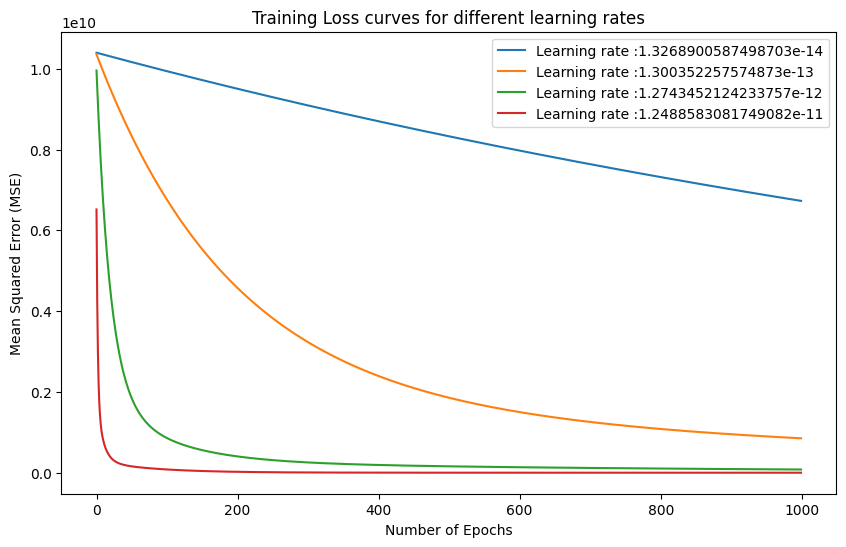

Learning rate:1.3268900587498703e-14, validation MSE: 5800919220.233118
Learning rate:1.300352257574873e-13, validation MSE: 527718080.2864878
Learning rate:1.2743452124233757e-12, validation MSE: 68158480.39460975
Learning rate:1.2488583081749082e-11, validation MSE: 2015151.7282523513


In [79]:
#Applying closed form solution to non-normalised data

raw_train_data = pd.read_csv(train_path)
raw_val_data = pd.read_csv(val_path)

#1. drop the ID column from training and validation data
unnormal_train_df = raw_train_data.drop(columns=['id'])
unnormal_val_df = raw_val_data.drop(columns=['id'])

#2. change date into 3 numerical features day, month and year, like in the warm up exercise

for df in [unnormal_train_df,unnormal_val_df]:
  df['date']=pd.to_datetime(df['date'], format='%m/%d/%Y')
  #extract month, day, and year into separate columns
  df['month'] = df['date'].dt.month
  df['day'] = df['date'].dt.day
  df['year'] = df['date'].dt.year
  #drop the original date column
  df=df.drop(columns=['date'],inplace= True)


#3. Adding column age_since_renovated and replacing "yr_renovated"

def calculate_building_age(row):
    if row['yr_renovated'] != 0:
        return row['year'] - row['yr_renovated']
    else:
        return row['year'] - row['yr_built']

for df in [unnormal_train_df, unnormal_val_df]:
    df['age_since_renovated'] = df.apply(calculate_building_age, axis=1)
    df.drop(columns=['yr_renovated'], inplace=True)

features = unnormal_train_df.columns.difference(['price'])

X_train = np.c_[np.ones(unnormal_train_df.shape[0]), unnormal_train_df[features]]
y_train = unnormal_train_df['price'].values
X_val = np.c_[np.ones(unnormal_val_df.shape[0]), unnormal_val_df[features]]
y_val = unnormal_val_df['price'].values
w = np.linalg.pinv(X_train.T @ X_train) @ X_train.T @ y_train
print("Weights\n")
print(f"Feature: intercept, Weight: {w[0]}") # Add 'intercept' as the first feature

for feature, weight in zip(features, w[1:]):
    print(f"Feature: {feature}, Weight: {weight}")

train_pred = X_train @ w

train_mse = np.mean((y_train - train_pred) ** 2)
print("\nMSE for Training data:", train_mse)
val_pred = X_val @ w
val_mse = np.mean((y_val - val_pred) ** 2)
print("\nMSE for Validation data:", val_mse)


def batch_gradient_descent(X, y, learning_rate, num_iterations, epsilon=None, convergence_threshold=None):

    # Add a column of ones to include the intercept term
    X_b = np.c_[np.ones((X.shape[0],1)),X]  # shape (n_samples, d+1)

    # Initialize weights
    np.random.seed(0)
    weights = np.random.randn(X_b.shape[1])


    losses = []  # List to store the loss at each iteration

    for iteration in range(num_iterations):
      gradients = 2/len(X_b) * X_b.T.dot(X_b.dot(weights) - y )
      weights=weights - learning_rate * gradients

      # MSE calculation
      y_pred = X_b.dot(weights)
      mse = np.mean((y_pred - y )** 2 )
      losses.append(mse)

      # checking convergence
      if epsilon is not None:
        if mse < epsilon :
          break
      if convergence_threshold is not None :
          if np.linalg.norm(gradients) < convergence_threshold:
            break

    return weights, losses



learning_rates = [9.8**-i for i in range(14,10,-1)]
num_iterations = 1000
convergence_threshold = 1e-6
epsilon = 1e-8

#Experiment with different learning_rates
final_weights = []
validation_mse = []
losses =[]

for rate in learning_rates :
  weights, loss = batch_gradient_descent(unnormal_train_df[features], y_train, rate, num_iterations, epsilon, convergence_threshold)
  final_weights.append(weights)
  losses.append(loss)

  #Compute MSE on validation data
  X_val_b = np.c_[np.ones(unnormal_val_df.shape[0]), unnormal_val_df[features]]

  y_val_pred = X_val_b.dot(weights)

  mse_val = np.mean((y_val_pred - y_val ) ** 2)
  validation_mse.append(mse_val)

# plot the training losses
plt.figure(figsize=(10,6))
for i, loss in enumerate(losses):
  if learning_rates[i]==1:
    continue
  plt.plot(range(len(loss)),loss,label=f"Learning rate :{learning_rates[i]}")

plt.xlabel('Number of Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training Loss curves for different learning rates')
plt.legend()
plt.show()

for i, mse in enumerate(validation_mse):
  print(f"Learning rate:{learning_rates[i]}, validation MSE: {mse}")



**Questions**

Please revisit the questions above. Does your experiment confirm your expectation?  Can you provide explanations to the observed differences (or lack of differences) between the normalized data and unnormalized data? Based on these observations and your understanding of them, please comment on the benefits of normalizing the input features in learning for linear regressions.


Yes, The experiment confirmed my expectations.

The weights for unnormalized data are quite small and can even be close to zero for some features, such as the intercept and `sqft_lot`. This means the model isn't doing a good job of understanding how these features relate to the target variable. In contrast, features with bigger values, like `lat` and `waterfront`, have much larger weights, showing that they have a stronger influence on the predictions. Normalization reduces the risk that features with larger value ranges dominate the model's predictions allowing for a more impartial representation of all features.

Also MSE for normalised train and test data is smaller as compared to unnormalised data, which means the model predictions are closer to the target values on average.

Benifits of normalizing the input features in linear regression are:

**Improved Model Performance**: When features are on a similar scale, the model can learn better, leading to more accurate predictions.

**Faster Convergence**: Normalized data helps the algorithm reach the best solution faster during training. This means the model will learn quicker and take fewer iterations to improve.

**Stability**: Normalized data reduces the risk of numerical issues during calculations, making the training process more stable.


## **3(b). (20 pts) Explore the impact of correlated features**

In the warm up exercise, you all have seen some features are highly correlated with one another. For example, there are multiple squared footage related features that are strongly correlated (e.g., *sqft_above* and *sqrt_living* has a correlation coefficient of 0.878).  This is referred to as multicollinearity phenomeon, where two or more features are correlated.

There are numerous consequences from multicollinearity. It makes it more challenging to estimate the weights of the features accurately. The weights may become unstable, and their interpretation becomes less clear.

In this part you will work with the pre-processed training set, and perform the following experiments **using the closed-form solution**.
Specifically, your code should:

1. Create five slighly different training sets, each of which is obtained by randomly subsample 75% of the orginial training set.
2. Use the closed-form solution of linear regression to fit the model on each of the five training sets.
3. For each model, report the learned weight vector in a table.
The table should have five rows (one for each model) and a column for each feature’s weight. Include a header row to clearly label the feature names for each column.
4. Compute the variance of the learned weight coefficients across the five models for each feature. This variance will serve as a measure of the **stability** of the weight assigned to each feature.

In [80]:
# Number of subsamples to generate
num_subsamples = 5
subsample_fraction = 0.75

# List to store weight vectors from each subsample
weights_list = []

# Create five subsamples and calculate weights for each using closed-form solution
for i in range(num_subsamples):
    # Randomly sample 75% of the training data without replacement
    subsample_df = train_df.sample(frac=subsample_fraction, random_state=i)

    # Prepare X and y for the subsample
    X_sub = np.c_[np.ones(subsample_df.shape[0]), subsample_df[features]]
    y_sub = subsample_df['price'].values

    # Closed-form solution on the subsample
    weights_sub = np.linalg.pinv(X_sub.T @ X_sub) @ X_sub.T @ y_sub
    weights_list.append(weights_sub)

# Convert the list of weight vectors to a DataFrame for easy analysis
weights_df = pd.DataFrame(weights_list, columns=['Intercept'] + features.tolist())
print("Weight Vectors from Different Subsamples:\n", weights_df)

# Calculate the variance of the weights across the five models for each feature
weight_variances = weights_df.var()
print("\nVariance of Weights Across Subsamples:\n", weight_variances)


Weight Vectors from Different Subsamples:
    Intercept  age_since_renovated  bathrooms  bedrooms  condition       day  \
0   5.362070            -0.154176   0.338113 -0.280649   0.170545 -0.049773   
1   5.359410            -0.152128   0.265747 -0.230422   0.198973 -0.048657   
2   5.363136            -0.011776   0.353731 -0.271090   0.175726 -0.034395   
3   5.365566            -0.151848   0.240452 -0.310284   0.225093 -0.066759   
4   5.346457            -0.119904   0.348320 -0.259355   0.191296 -0.049236   

     floors     grade       lat      long  ...  sqft_basement  sqft_living  \
0 -0.018366  1.124965  0.846749 -0.276303  ...       0.149856     0.818178   
1  0.062894  1.234219  0.812042 -0.274539  ...       0.185751     0.675581   
2  0.025311  1.125696  0.836203 -0.335214  ...       0.140682     0.746785   
3  0.082098  1.144139  0.828441 -0.283588  ...       0.194643     0.733742   
4 -0.028118  1.053304  0.848799 -0.323829  ...       0.112256     0.801248   

   sqft_livin

### **Questions**

Ideally, we would like the weight coefficients to be stable across different runs, as this increases confidence in the model's reliability. Do highly correlated features tend to exhibit more instability in their weights across different training sets compared to less correlated features? Discuss any trend you observe based on the variance of the weight coefficients. How does the stability of these features relate to the multicollinearity issue present in this dataset?


Yes, highly correlated features do tend to show more instability in their weight coefficients when we run the model on different training sets.

For example,the features sqft_living and sqft_above are likely to be positively correlated. Homes with larger living areas generally have more square footage above ground.

However in one run, sqft_living could have a weight of 0.82, while sqft_above might show a weight of 0.65.In another run, sqft_living could drop to 0.45, and sqft_above could rise to 0.72.

The feature year_built is less likely to be correlated with other features like waterfront. If we examine the weight coefficient for year_built, we might find it consistently around 0.10 across different training runs.

This happens because, with multicollinearity, it’s difficult for the model to decide which of the correlated features should get more weight. As a result, the importance can shift between these features across different runs, leading to inconsistent weights.

# Bonus. In-class competition (5 bonus pts)

We will host a in-class competition using the IA1 data, where you are encouraged to explore different ways to improve the prediction performance by manipunating the data. This could include: feature engineering such as removing, transforming features, constructing new features based on existing ones, using different encoding for the discrete features; data manipulation such as identifying and removing potential outliers; and target manipulation such as log transforming the price target. This is where you can get creative and test your ideas out.

To participate in this competition, use the following link:
https://www.kaggle.com/t/7a885211273e48968e3a5f1b556cb685

You should continue working in the same team for this competition. The training and validation data provided on the kaggle site are the same as the IA1 assignment. To participate, you will need to train your model and apply it to testing data provided on kaggle, and submit prediction files to be scored.

Your scoring will have two parts, the performance on the public leader board as well as the private leader board. The results on the public leader board is visible through out the competition so that you can gauge how well your model is performing in comparison to others. The private leader board shows the final evaluation performance and will be released only once after the competition is closed.

Each team will be allowed to submit 3 final entries to be evaluated. You can use the public leaderboard performance to pick which models to use for your final evaluation entries.

**Assginment of the bonus points:**

**Performance bonus:** the top 3 teams on the **private** leader board will recieve 5 bonus points.

**Participation bonus:** the 5 teams that submitted the most entries (with different performances) will recieve 3 bonus points. Also any team that participated the competition and got non-trivial performance will receive 2 bonus points.

Bonus points are capped at 5.


**Please provide the team name on the kaggle competition here _________.
Leave it blank if you opt not to participate.**

In [85]:
#running this code block will convert this notebook and its outputs into a pdf report.
!jupyter nbconvert --to html /content/gdrive/MyDrive/AI534/IA1-2024.ipynb  # you might need to change this path to appropriate value to location your copy of the IA0 notebook

input_html = '/content/gdrive/MyDrive/AI534/IA1-2024.html' #you might need to change this path accordingly
output_pdf = '/content/gdrive/MyDrive/AI534/IA1output.pdf' #you might need to change this path or name accordingly

# Convert HTML to PDF
pdfkit.from_file(input_html, output_pdf)

# Download the generated PDF
files.download(output_pdf)

[NbConvertApp] Converting notebook /content/gdrive/MyDrive/AI534/IA1-2024.ipynb to html
[NbConvertApp] Writing 911818 bytes to /content/gdrive/MyDrive/AI534/IA1-2024.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>